Question 1.

Part A:

a.

A configuration is a complete specification of a robot's pose, it tells us its position and orientation. The configuration space (C-space) is the set of all possible configurations. Its dimensions equal the robot's number of degrees of freedom. A planner searches this space. Any robot becomes a point in C-space. 

For a point robot, the C-space is (x, y), making it 2D and identical to the map. 

X- position along the road's plane's x-axis. Y- position along the road's plane's y-axis.

We do not consider the z-axis, as we know the terrain of the campus; as long as we know the x and y coordinates, we will know the height, as it has to be touching the ground. Therefore, there's no need for another dimension. It's said to be holonomic: it can move directly in any direction. For the buggy, the C-space becomes 3D. It includes (x, y, θ), since it has a body with a front. So the same (x, y) at different headings is a different configuration. Obstacles are mapped to C_obs, the set of configurations where the body overlaps an obstacle. C_free is the rest. C_obs depends on θ: a buggy with length L m could fit through a gap when aligned, but not when sideways. Planning means finding a continuous path in C_free from start to goal. 

The buggy has 3 configuration dimensions, but only 2 controls (speed (v), steering(δ)). The buggy is non-holonomic as it cannot move sideways. Since this is a velocity constraint, and not a position constraint, the C-space is still 3D. So, the spot right next to the buggy is in C_free and is reachable, just not directly, and only through a manoeuvre, like parallel parking. Furthermore, steering is a control input, not a part of the configuration, and is bounded by δ_max. It becomes a state only if you model a steering-rate limit.

Not every path through C_free is drivable. The steps must respect the turning limit, and the planner must search 3D.
This leads to A(b), minimum turning radius, and A(c), Hybrid A*.

PS. Why steering isn't a dimension: dimension answers where the buggy is, and steering doesn't do that. Heading is a dimension because it's part of the pose; it can't be changed instantly, and it affects collisions. Whereas steering is something you control. The idea behind the steering-rate limit making steering a state is that a variable is a state if its value now limits what it can be a moment later. Instant steering: the buggy can go from straight to the tightest turn immediately. Rate-limited steering: the wheel has to turn first, so the path's curvature has to change gradually. A planner needs to know the current δ to know what turns are possible next. It's still not a dimension, though. This would in turn make the buggy have 4 states while only having 2 controls, hence making it even more constrained. Theta is a dimension because it's required to know where one exact spot on the buggy is.

Dimension: one independent number (axis) of a space. 3 dimensions mean 3 numbers needed to point to one spot in that space.
State: the full set of numbers you must remember now to predict what can happen next. Each number in it is one dimension of the state space.

Finally, all this matters to a planner because:
1. The search space is bigger. Since there's an additional parameter θ involved now.
   
3. Collision checking depends on θ. For a point robot, a cell is either blocked or free. But for a buggy C_obs is 3D; it might be blocked at one heading and free at another. So the planner needs to check the body's footprint at every heading to see if something is truly an obstacle or not.

4. Not every neighbour is reachable. So the planner's moves can't be "jump to the next cell". Each move must be a drivable arc.

5. The goal needs to include heading. A point robot only needs to reach a position. The buggy needs to arrive at a pose. For example, it must be lined up with the road, not facing a wall.

---------------------------------------

b.
    


To compute R_min, we use the kinematic bicycle model. The two front wheels are replaced by one wheel at the middle of the front axle (F), and the two rear wheels by one wheel at the middle of the rear axle (P). The distance between them is the wheelbase, FP = L = 2.30 m. Only the front wheel steers, and it is turned by the steering angle δ away from the direction the body is pointing.

The images attached show the derivation of R_min and we can see using R_min = L / tan δ_max, we get R_min = 3.68 m. 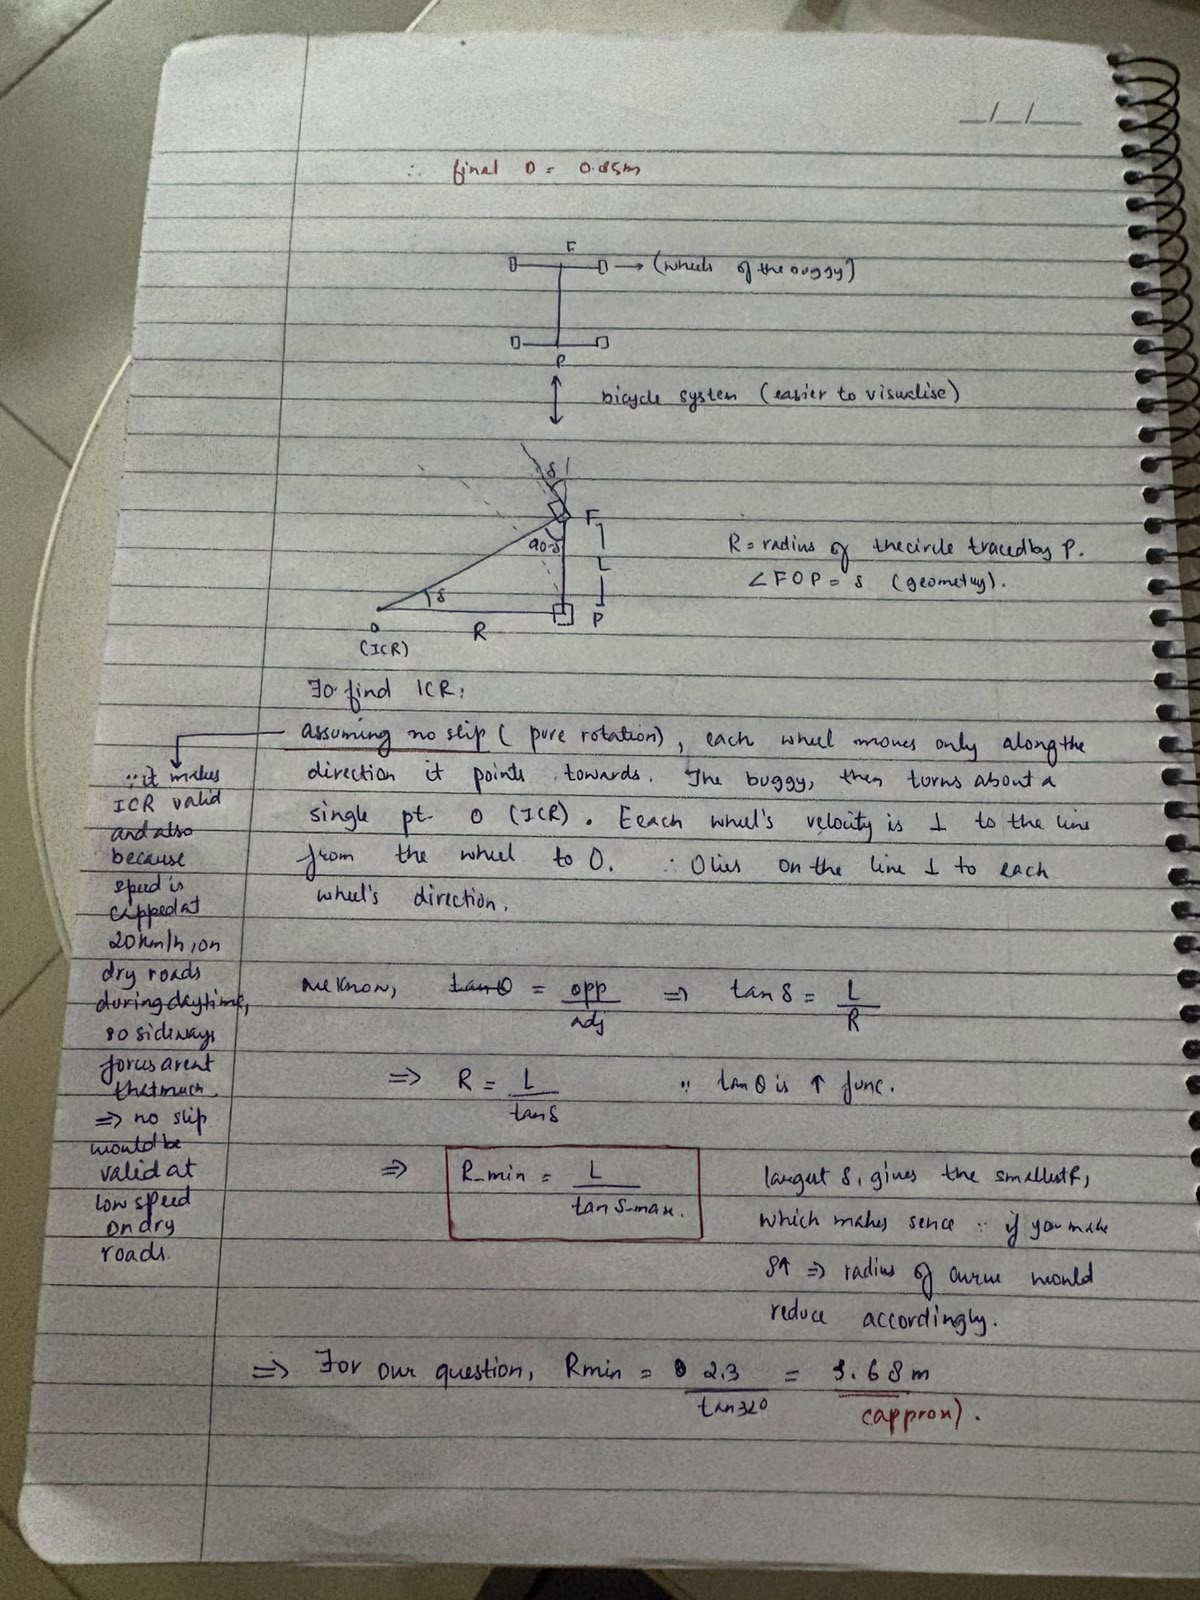

Grid A* path searches only (x, y) on a grid. It moves between neighbouring cell centres and minimises length. Its output is  polyline, so heading can change by 45° or 90° at a single vertex. The explaining is done as follows:
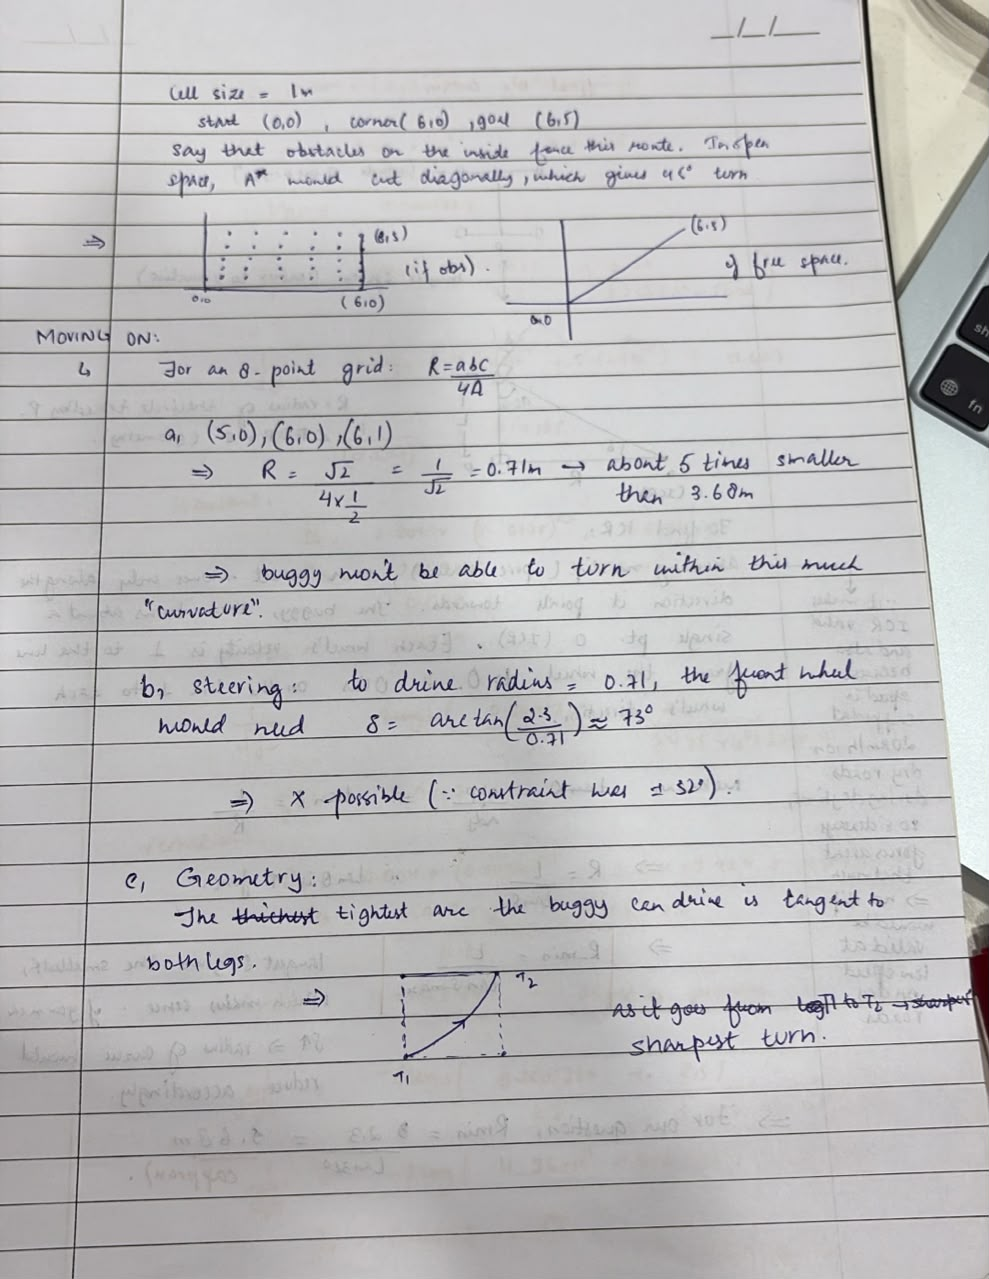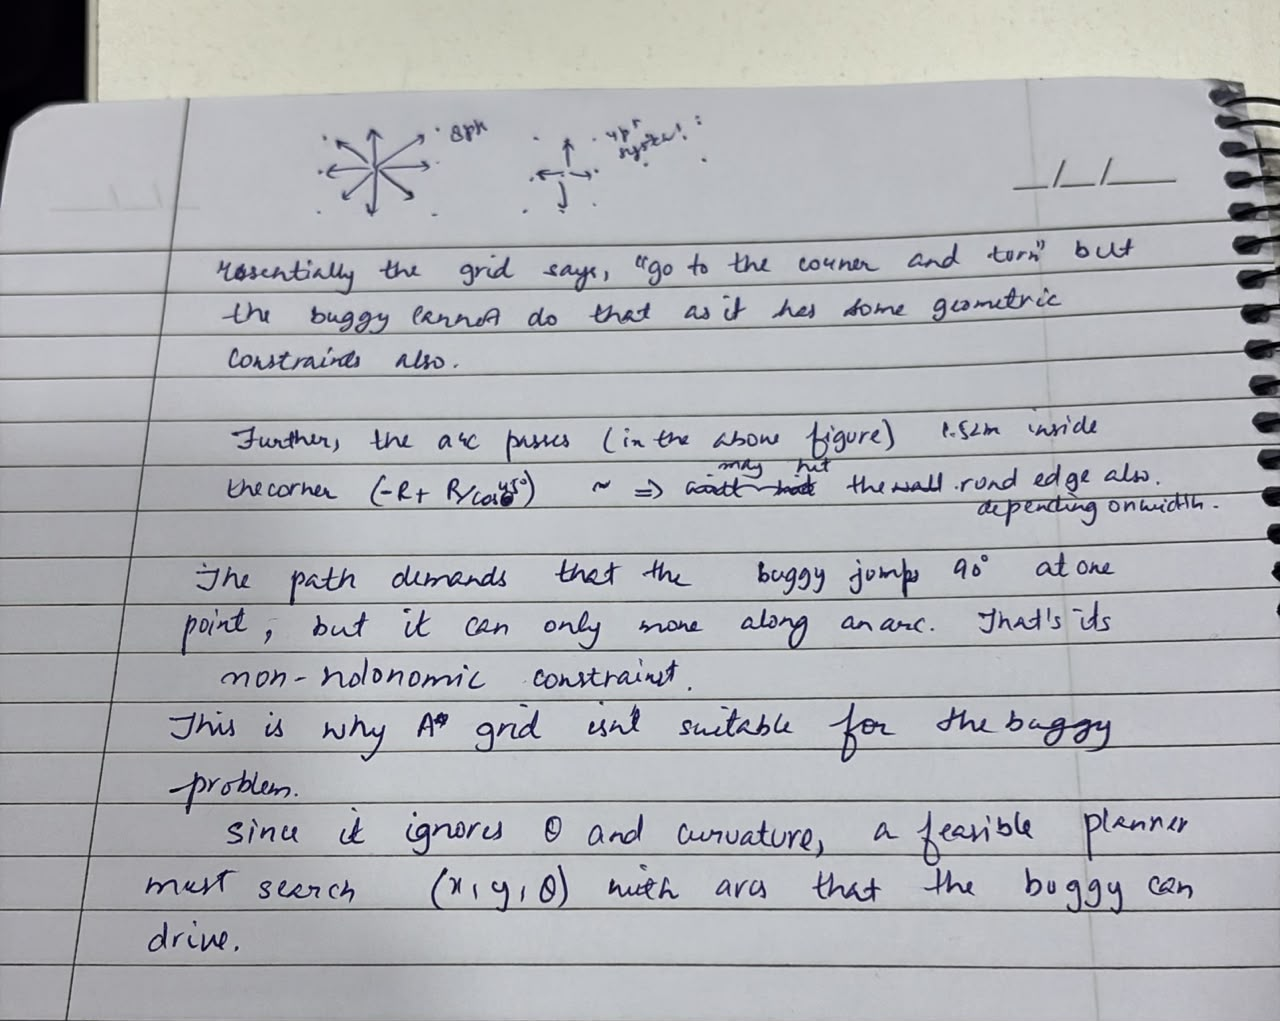

----------------------------------------------------------------

c.

Grid A* plans positions (x, y) and hops between cell centres. The path it returns has instant turns, which is why it fails for a real buggy. Hybrid A* keeps the A* search but changes what a "step" is, so the entire path it maps is something the car/buggy can actually drive. Furthermore, it's also non-holonomic with a turning limit, and as a result every edge is drivable and it searches the buggy's real 3D C-space. It can also ask for a goal heading. This is why it's more suitable for a car-like vehicle like the buggy.

How it works: 

1. State is continuous(x, y, θ). A node isn't a single cell at a particular (x, y) anymore. It's an exact pose e.g., (3, 6, 52°).

2. It doesn't ask "which neighbouring cell do I go to?" Instead, it asks "which steering command can I give?"  The three steering commands are: full left, full right and straight. For each, we simulate driving a short distance using that command, and as a result, we get a real arc and a new pose for the buggy. Because δ stays within ±32°, every arc has a radius ≥ 3.68 m. Every move is drivable by construction, which fixes the issue with A*.

3. Cost: Length, plus penalties you choose, for example for reversing, switching direction, and big steering angles or steering changes. 

4. Heuristic. There will be two cheap estimates that the buggy can take, and we will take the larger one. The two estimates are:
One that respects the car's turning limits but ignores obstacles (a precomputed table of shortest drivable curves).
One that respects obstacles but ignores turning limits (a plain 2D grid search from the goal).

5. Prune with the grid: At each step, there are three steering choices, and after say about 10 steps it gives 3^10 paths, which is way too many. Many of them even end up at nearly the same pose. So, to prevent this, we split each (x, y, θ) space into boxes ( a small (x, y) cell and a small heading range of ~5° each). This reduces the number of paths significantly, and amongst the somewhat similar ones, we end up only choosing the one with the least cost.

Two states in the same box are almost the same pose, so the cheaper one can do everything the other can, only cheaper (lesser penalties). It's an approximation, because they aren't exactly equal. That's the reason Hybrid A* isn't guaranteed optimal or complete, it costs more computation, and it depends on choices such as the step length, the set of steering angles and the box size.

Also, the grid's main job here isn't to define the nodes, but to check whether one already exists; if it does, it keeps the cheaper one.

6. Analytical expansion: We directly connect a curve straight from the current pose to the goal pose. If this doesn't hit anything, that's the path the buggy would take. This saves time in open areas. 

-----------------------------------

Part B:

d. 

In [2]:
import heapq, math
import numpy as np
import matplotlib.pyplot as plt

# - a cell is (row, col): row goes down, col goes right
# - grid value 1 = free, 0 = blocked
# - one cell = 1 m
CELL_SIZE = 1.0

In [3]:
def in_bounds(grid, cell):
    r, c = cell
    height, width = grid.shape
    if(0 <= r < height and 0 <= c < width):
        return True
    else:
        return False
        
def make_grid(height, width, obstacles=(), rects=()):
    """
    obstacles: list of (row, col) cells to block
    rects: list of (r0, c0, r1, c1), blocking every cell from r0..r1, c0..c1 inclusive
    returns: np.ndarray of shape (height, width), 1 = free, 0 = blocked
    """
    grid = np.ones((height, width), dtype=int)
    for r, c in obstacles:
      if not in_bounds(grid, (r, c)):
          raise ValueError(f"obstacle {(r, c)} is outside the grid")
      grid[r, c] = 0
        
    for r0, c0, r1, c1 in rects:
        if not (in_bounds(grid, (r0, c0)) and in_bounds(grid, (r1, c1))):
            raise ValueError(f"rectangle {(r0, c0, r1, c1)} is outside the grid")
        if r0 > r1 or c0 > c1:
            raise ValueError(f"rectangle {(r0, c0, r1, c1)} has its corners reversed")
        grid[r0:r1 + 1, c0:c1 + 1] = 0
    return grid

In [4]:
def validate(grid, start, goal):
    height , width = grid.shape
    if not in_bounds(grid, start):
        raise ValueError(f"start {start} is outside the {height}x{width} grid")
        
    if not in_bounds(grid, goal):
        raise ValueError(f"goal {goal} is outside the {height}x{width} grid")
    r, c = start
    r2, c2 = goal
    if(grid[r,c] == 0):
        raise ValueError(f"start {start} is blocked")
    if(grid[r2, c2] == 0):
        raise ValueError(f"goal {goal} is blocked")

In [5]:
#checking for issues:
g = make_grid(5, 5, obstacles=[(1, 1)])
validate(g, (0, 0), (4, 4))      # should pass silently
validate(g, (1, 1), (4, 4))      # should raise "start ... is blocked"
validate(g, (0, 0), (5, 5))      # should raise "goal ... outside"

ValueError: start (1, 1) is blocked

In [6]:
g = make_grid(5, 5, obstacles=[(1, 1), (2, 3)], rects=[(3, 0, 4, 1)])
print(g)

[[1 1 1 1 1]
 [1 0 1 1 1]
 [1 1 1 0 1]
 [0 0 1 1 1]
 [0 0 1 1 1]]


In [7]:
def neighbours(grid, cell, allow_corner_cutting=False):
    r, c = cell
    out = []
    for dr in (-1 , 0, 1):
        for dc in (-1, 0, 1):
            new_cell = (r + dr, c + dc)
            if not in_bounds( grid, new_cell) or grid[r + dr, c + dc] == 0:
                continue
            if(dr == 0 and dc == 0):
                continue
            if(dr != 0 and dc != 0):
                cost = math.sqrt(2)
                if not allow_corner_cutting:
                    if( grid[r + dr, c] == 0 or grid[r, c + dc] == 0):
                        continue
            else:
                cost = 1
            out.append((new_cell, cost))
            
        
    return out   # list of ((row, col), step_cost)

In [8]:
#checking:
#g = make_grid(4, 4, obstacles=[(1, 2)])
#print(neighbours(g, (1, 1)))
#print(neighbours(g, (1, 1), allow_corner_cutting=True))
#print(neighbours(g, (0, 0)))

In [9]:
def heuristic(cell, goal):
    dr = abs(cell[0] - goal[0])
    dc = abs(cell[1] - goal[1])
    diag_steps = min(dr, dc)
    straight_steps = max(dr, dc) - min(dr, dc)
    total = diag_steps*math.sqrt(2) + straight_steps
    return total

In [10]:
def astar(grid, start, goal, allow_corner_cutting=False):
    start, goal = tuple(start), tuple(goal)      # lists would crash as dict keys
    validate(grid, start, goal)                  # out of bounds or blocked: raises

    open_heap = [(heuristic(start, goal), start)]    # entries are (f, cell)
    g = {start: 0}                                   # cheapest known cost to each cell
    came_from = {}                                   # cell -> where we came from
    closed = set()                                   # cells already expanded
    explored = []                                    # expansion order, for the plot

    while open_heap:
        f, cell = heapq.heappop(open_heap)
        if cell in closed:                           # stale duplicate entry
            continue
        closed.add(cell)
        explored.append(cell)

        if cell == goal:                             # first pop of goal = cheapest route
            path = [cell]
            while cell in came_from:
                cell = came_from[cell]
                path.append(cell)
            return path[::-1], explored

        for nb, step in neighbours(grid, cell, allow_corner_cutting):
            new_g = g[cell] + step
            if nb not in g or new_g < g[nb]:         # new cell, or a cheaper route
                g[nb] = new_g
                came_from[nb] = cell
                heapq.heappush(open_heap, (new_g + heuristic(nb, goal), nb))

    return None, explored                            # heap empty: no path exists

In [11]:
# wall the goal in: should return None
g2 = make_grid(5, 5, rects=[(0, 2, 4, 2)])
print(astar(g2, (0, 0), (4, 4))[0])
# corner cutting on: the path should be shorter or equal in cost
print(astar(g, (0, 0), (4, 4), allow_corner_cutting=True)[0])

None
[(0, 0), (1, 0), (2, 1), (3, 2), (3, 3), (4, 4)]


In [12]:
def plot_result(grid, path, explored, start, goal, title="Grid A*"):
    plt.imshow(grid, cmap="gray", vmin=0, vmax=1)

    plt.plot([c for r, c in explored], [r for r, c in explored], "bo", label="explored")

    if path is not None:
        plt.plot([c for r, c in path], [r for r, c in path], "r-", label="path")

    plt.plot(start[1], start[0], "gs", markersize=10, label="start")
    plt.plot(goal[1], goal[0], "y*", markersize=15, label="goal")

    plt.title(title)
    plt.xlabel("col")
    plt.ylabel("row")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.show()

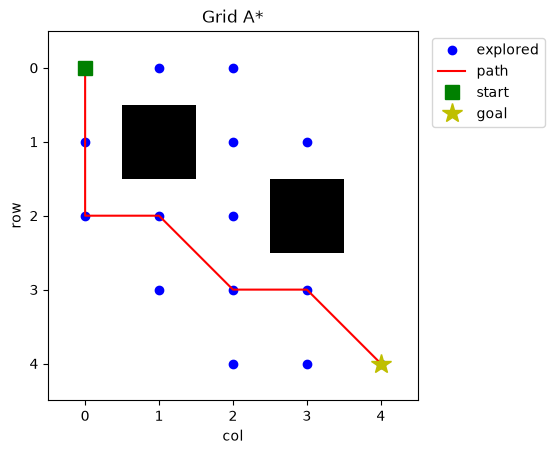

In [13]:
grid_a = make_grid(5, 5, obstacles=[(1, 1), (2, 3)])
path, explored = astar(grid_a, (0, 0), (4, 4))
plot_result(grid_a, path, explored, (0, 0), (4, 4))

------------------------------

e.

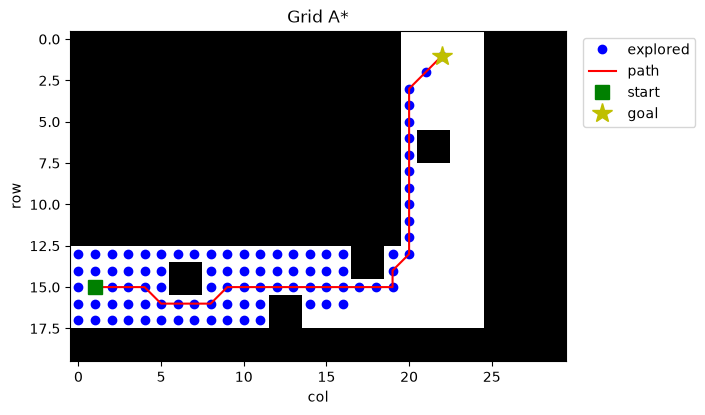

In [14]:
walls = [(0, 0, 12, 19), (18, 0, 19, 29), (0, 25, 17, 29)]
obstacles = [(14, 6, 15, 7), (16, 12, 17, 13), (13, 17, 14, 18), (6, 21, 7, 22)]
road = make_grid(20, 30, rects = walls + obstacles)
start, goal = (15, 1), (1, 22)
path, explored = astar(road, start, goal, allow_corner_cutting=False)
plot_result(road, path, explored, start, goal, title = "Grid A*")

-----

f.

(15, 4) need 1.52 m, runs 3.00 / 1.41 m FAIL
(16, 5) need 1.52 m, runs 1.41 / 3.00 m FAIL
(16, 8) need 1.52 m, runs 3.00 / 1.41 m FAIL
(15, 9) need 1.52 m, runs 1.41 / 10.00 m FAIL
(15, 19) need 3.68 m, runs 10.00 / 1.00 m FAIL
(14, 19) need 1.52 m, runs 1.00 / 1.41 m FAIL
(13, 20) need 1.52 m, runs 1.41 / 10.00 m FAIL
(3, 20) need 1.52 m, runs 10.00 / 2.83 m OK


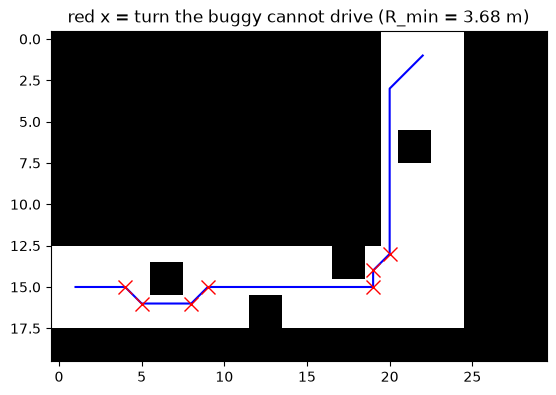

In [17]:
R_MIN = 3.68

# 1. corners = cells where the direction changes
corners = []
for i in range(1, len(path) - 1):
    d1 = (path[i][0] - path[i-1][0], path[i][1] - path[i-1][1])
    d2 = (path[i+1][0] - path[i][0], path[i+1][1] - path[i][1])
    if d1 != d2:
        corners.append(i)
points = [0] + corners + [len(path) - 1]      # start, corners, goal

# 2. check each corner
need_at = [0.0] * len(points)                  # start and goal need nothing
for n in range(1, len(points) - 1):
    i = points[n]
    d1 = (path[i][0] - path[i-1][0], path[i][1] - path[i-1][1])
    d2 = (path[i+1][0] - path[i][0], path[i+1][1] - path[i][1])
    turn = abs(math.degrees(math.atan2(d2[0], d2[1]) - math.atan2(d1[0], d1[1])))
    turn = min(turn, 360 - turn)
    need_at[n] = R_MIN * math.tan(math.radians(turn / 2))

bad = []
for n in range(1, len(points) - 1):
    i = points[n]
    before = math.dist(path[points[n-1]], path[i]) * CELL_SIZE
    after  = math.dist(path[i], path[points[n+1]]) * CELL_SIZE
    ok = (before >= need_at[n-1] + need_at[n]) and (after >= need_at[n] + need_at[n+1])
    print(path[i], f"need {need_at[n]:.2f} m, runs {before:.2f} / {after:.2f} m", "OK" if ok else "FAIL")
    if not ok:
        bad.append(path[i])

# 3. plot
plt.imshow(road, cmap="gray", vmin=0, vmax=1)
plt.plot([c for r, c in path], [r for r, c in path], "b-")
plt.plot([c for r, c in bad], [r for r, c in bad], "rx", markersize=10)
plt.title("red x = turn the buggy cannot drive (R_min = 3.68 m)")
plt.show()

--------------------

Part C:

The planner can only compare two paths using one number, which is exactly what the cost function gives him. It combines everything we care about and weighs it by how much it would affect the cost. 

Total cost = length + turning + closeness to obstacles + jerkiness of steering

All four terms explained:
1. Path length:
Longer means more time and energy. If this were the only term, we would just pick the shortest path.

2. Curvature (κ):
Curvature is how sharply the path bends. It's the inverse of turning radius. Sharp bends mean large steering angles, tyre scrubbing and discomfort. We use ∫κ² ds, meaning we add up κ² along the path. Squaring does two things: the sign doesn't matter (left and right bends both cost), and one very sharp bend costs more than several gentle ones.

3. Obstacle clearance (d):
d is the distance from the buggy to the nearest obstacle. The cost should be lower when the buggy is far away, hence safer, and higher when it's close. We put some reasonable value for d_safe and if d < d_safe, we reject the path outright with a hard constraint

4. Steering change between steps (Δδ):
δ is the steering angle. Cost = Σ(δ_next − δ_current)². Curvature tells us how much we turn; this tells us how quickly. A curve could have decent curvature, but we might change our mind about taking it at the last moment; hence the steering angle would change significantly, and in such a situation it destabilises the buggy and also wears the actuator, hence more cost.

Putting it all together, we get:

J = w_L·L + w_κ·∫κ² ds + w_c·∫φ(d) ds + w_Δ·Σ(Δδ)²
Before moving on, we need to normalise each term. Otherwise, say if L = 60m and k = 0.02, then it would be meaningless in comparison, and the term wouldn't have much contribution. 

Choosing between Path 1 and Path 2:

It would depend on the weights set for each term, and whichever one has a lower cost would be chosen. For a buggy where safety matters, I would give a high weight to w_c and w_k, so path 2 would usually win unless it's MUCH longer. 

What goes wrong if one weight is too high:

Length:	Cuts corners, hugs obstacles, sharp turns

Curvature:	Huge detours, no feasible path in tight spaces

Steering change:	Can't turn sharply when needed, so it reacts late and overshoots

Clearance: 	Refuses narrow but passable gaps, may find no path


5 km/h vs 20 km/h:

Lateral acceleration is given by a = v²κ. 5 km/h ≈ 1.4 m/s and 20 km/h ≈ 5.6 m/s. Speed is 4× higher, so v² is 16× higher. The same curve that is gentle at 5 km/h is violent at 20.

Also, stopping distance is proportional to v² and tracking error grows with speed, so the buggy needs more clearance at high speed.

At 20 km/h: we need to make w_κ, w_Δ and d_safe larger since the buggy is at a decent speed. Path 2 wins: smooth and wide is safer to track, even if longer.

At 5 km/h: dynamic effects are small; the buggy can turn tightly and stop quickly. Path 1 can win, provided it still satisfies d_safe, because saving distance matters more.

-----------

Q2.

Part A:

a.

The concept of the velocity model is as follows:
Let the position at some time be p_t = (x_t, y_t)
then, velocity (v) = (p_t - p_t-1)/dt

and p_(t+k) = p_t + k.v.dt
i.e, it'll keep moving in a straight line at that velocity. 

Why this works in some situations:
1. Inertia :
A walking person or moving object cannot change its velocity instantly over a short period of time. Hence, over a short horizon, the most reasonable guess for what happens next is that it continues to move the way it has been till now.

2. Most motion is boring:

Most of the time, people walking on a road don't instantly change their position, speed, or way of moving. They're mostly moving at a steady pace. In such a case, the concept of constant velocity sits just right.

3. Short horizons hide mistakes:

A small error in velocity only becomes a big error in position once enough time has passed. 

4. It has no parameters to tune and hence cannot overfit:

It works on any dataset, agent, and with no training; since it's a very simple formula that only requires u to know the velocity of the moving object/person. This makes it very easy to use also.

Where it fails:
Assume the person walks at a speed of 1.5m/s and a 3s horizon ( how far ahead were looking)

Situation:  Person stops  ;                   What CV predicts:  Keeps walking
                      
Situation:  Sharp 90° turn after 1 s   ;      What CV predicts:  Straight line

Situation:  Avoids another pedestrian    ;    What CV predicts:  Walks straight through them

Situation:  Decides to cross the road    ;    What CV predicts:  Carries on along pavement

Further, it also fails because:
1. Error grows linearly with the horizon:

If assumed velocity is wrong by Δv, the miss is Δv × T. Doubling the horizon doubles the error. Hence, over time it would accumulate to a large number.

2. It doesn't consider anything except the object/person's last step:

It doesn't consider walls, other people, crossings, etc. and only assumes that the person can walk wherever he wants and would always walk at a constant velocity.

What recent trajectory can offer for a better prediction:

1. Smooth or weighted velocity.


How to get it from positions: Average the last N step velocities, giving recent ones more weight

What it fixes: position noise (error) 

Catch: Lags behind real change( since averages old steps also, and they describe the past)

2. Acceleration.

How to get it from positions: Change in velocity between steps. (or fit a parabola)

What it fixes: speeding up or slowing down, starting or stopping

Catch: its a change of change, so tiny measurement error would lead to huge error in this as its scaled twice. 

3. Change in heading( turn rate).

How to get it from positions: Angle between consecutive displacement vectors, divided by dt

What it fixes: Curved paths and turns

Catch: unreliable when the person is at rest, barely moving

4. Polynomial curve fitting.

How to get it from positions: Least-squares curve through the last N points.

What it fixes: Noise, plus ensures gentle curvature

Catch: overfitting. (A very flexible curve can pass through every data point, including the jitter. It looks perfect on the past, but past the last point it can swing off in a random direction. A simple curve (a line or a gentle parabola) is safer.)

5. Kalman filter.

How to get it from positions: Blend a motion model with each new noisy measurement

What it fixes: Noise, plus an estimate for uncertainty.

Catch: The filter cleans up noise well, but it still relies on a built-in assumption such as "the person keeps walking straight".

6. Nearby agents(interaction).

How to get it from positions: Distances and relative velocities to others

What it fixes: Collision avoidance, group walking

Catch: needs everyone's tracks, hence will be harder to build and tune. 


-----------

Part B:


b.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/maleehaharis/Downloads/biwi_eth.txt", sep="\t", header=None, names=["frame", "id", "x", "y"])
print(df.head())

   frame   id      x     y
0    780  1.0   8.46  3.59
1    790  1.0   9.57  3.79
2    800  1.0  10.67  3.99
3    800  2.0  13.64  5.80
4    810  1.0  11.73  4.32


   frame   id      x     y
0    780  1.0   8.46  3.59
1    790  1.0   9.57  3.79
2    800  1.0  10.67  3.99
4    810  1.0  11.73  4.32
6    820  1.0  12.81  4.61


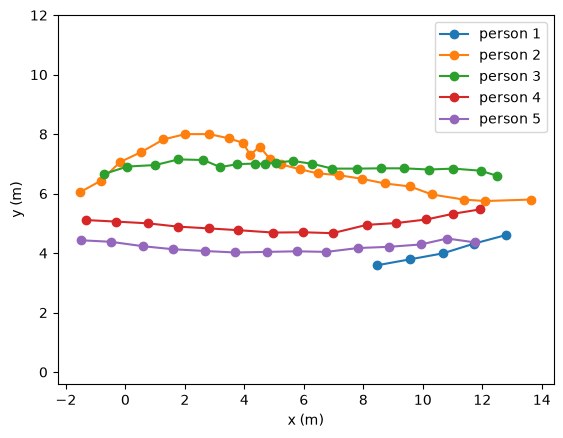

In [46]:
person = df[df["id"] == 1]            # only the rows of person 1
print(person)

for pid in df["id"].unique()[:5]:     # first 5 people
    rows = df[df["id"] == pid]
    plt.plot(rows["x"], rows["y"], "o-", label="person " + str(int(pid)))

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.axis("equal")
plt.show()

One trajectory is the path of one pedestrian, recorded by a fixed overhead camera in the ETH dataset. It's a time-ordered list of (x, y) positions in metres. Each row of the file is frame, person id, x, y, and a new position is recorded every 10 frames, which is every 0.4 seconds (2.5 samples per second).

------------

c.

I predicted from the last 8 observed positions (3.2 s). The velocity is the difference between the last two positions, and I extended it in a straight line for 3 steps (1.2 s) and 8 steps (3.2 s). Over 1 s the prediction stays close to the true path. Over 3 s it drifts, because pedestrians slow down, stop or change direction, which constant velocity cannot know.

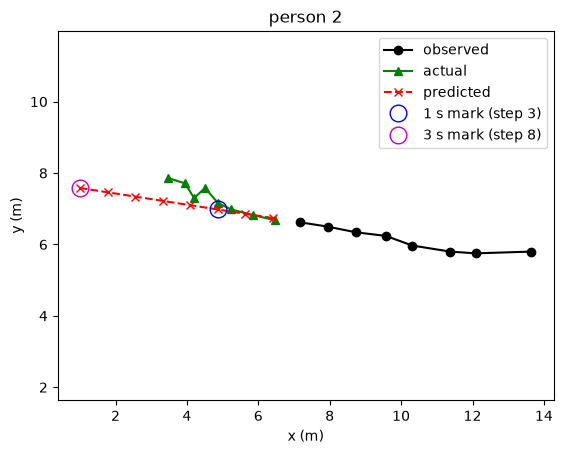

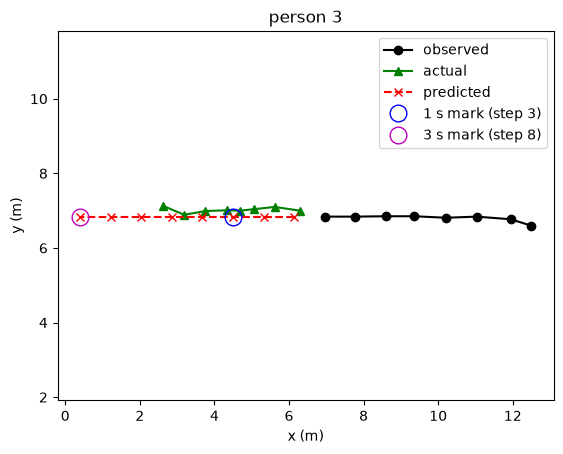

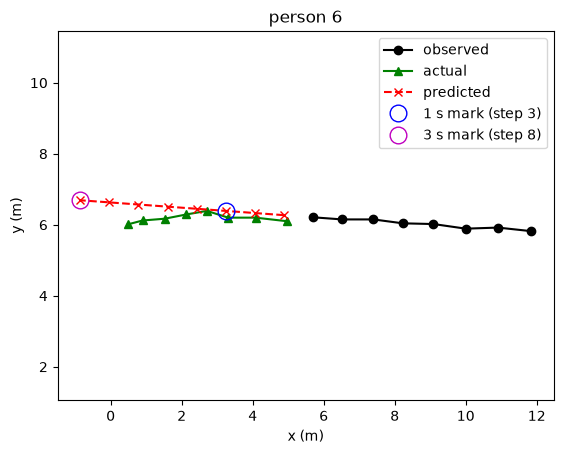

In [47]:
import numpy as np

for pid in [2, 3, 6]:                            # 3 example people
    path = df[df["id"] == pid].sort_values("frame")[["x", "y"]].values    # this person's (x, y) points
    if len(path) < 16:
       print("ID", pid, "too short")
       continue
    obs = path[:8]                               # first 8 points = observed
    actual = path[8:16]                          # next 8 points = real future

    v = obs[-1] - obs[-2]                        # velocity = last point - the one before
    pred = []
    for k in range(1, 9):
        pred.append(obs[-1] + k * v)             # k steps ahead = last point + k * velocity
    pred = np.array(pred)

    plt.figure()
    plt.plot(obs[:, 0], obs[:, 1], "ko-", label="observed")
    plt.plot(actual[:, 0], actual[:, 1], "g^-", label="actual")
    plt.plot(pred[:, 0], pred[:, 1], "rx--", label="predicted")
    plt.plot(pred[2, 0], pred[2, 1], "bo", markersize=12, fillstyle="none", label="1 s mark (step 3)")
    plt.plot(pred[7, 0], pred[7, 1], "mo", markersize=12, fillstyle="none", label="3 s mark (step 8)")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title("person " + str(pid))
    plt.axis("equal")
    plt.legend()
    plt.show()

-----

d.

In [48]:
def cv_predict(obs, n):
    v = obs[-1] - obs[-2]                  # velocity: last point minus the one before
    pred = []
    for k in range(1, n + 1):
        pred.append(obs[-1] + k * v)       # k steps ahead = last point + k * velocity
    return np.array(pred)

def wv_predict(obs, n):
    vels = obs[1:] - obs[:-1]              # velocity of each step
    v = (1*vels[-4] + 2*vels[-3] + 3*vels[-2] + 4*vels[-1]) / 10   # newest counts most
    pred = []
    for k in range(1, n + 1):
        pred.append(obs[-1] + k * v)
    return np.array(pred)

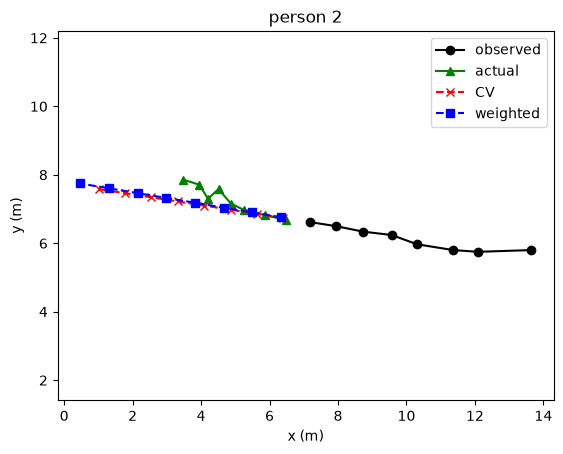

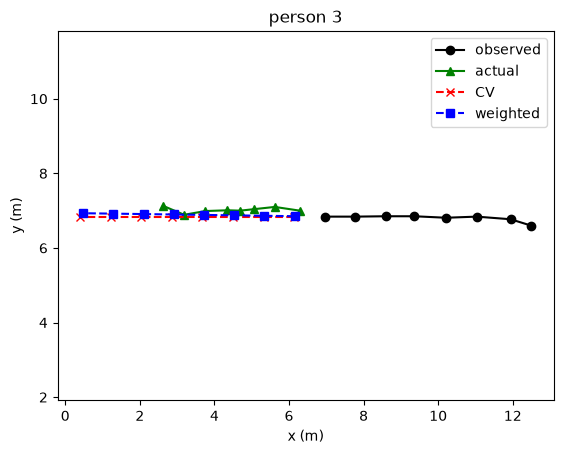

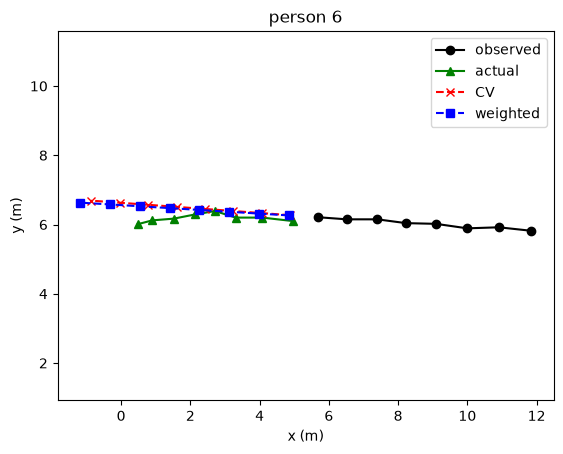

In [49]:
import numpy as np
import matplotlib.pyplot as plt

weights = np.array([1, 2, 3, 4, 5, 6, 7])
weights = weights / weights.sum()            # weights add up to 1

for pid in [2, 3, 6]:
    path = df[df["id"] == pid].sort_values("frame")[["x", "y"]].values
    if len(path) < 16:
        print("ID", pid, "too short")
        continue

    obs = path[:8]
    actual = path[8:16]

    # CV baseline: last step only
    v_cv = obs[-1] - obs[-2]

    # weighted: all 7 steps, recent ones count more
    steps = np.diff(obs, axis=0)             # 7 step velocities
    v_w = np.sum(weights[:, None] * steps, axis=0)

    pred_cv = []
    pred_w = []
    for k in range(1, 9):
        pred_cv.append(obs[-1] + k * v_cv)
        pred_w.append(obs[-1] + k * v_w)
    pred_cv = np.array(pred_cv)
    pred_w = np.array(pred_w)

    plt.figure()
    plt.plot(obs[:, 0], obs[:, 1], "ko-", label="observed")
    plt.plot(actual[:, 0], actual[:, 1], "g^-", label="actual")
    plt.plot(pred_cv[:, 0], pred_cv[:, 1], "rx--", label="CV")
    plt.plot(pred_w[:, 0], pred_w[:, 1], "bs--", label="weighted")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title("person " + str(pid))
    plt.axis("equal")
    plt.legend()
    plt.show()

For the improved predictor, I went with the weighted velocity model. It uses a weighted average of the last 4 velocities instead of just the last one. I expect it to help because a single step's velocity is noisy, and averaging reduces that noise, while the higher weight on recent steps still lets it follow changes in speed or direction. The weights are fixed, so no tuning data is needed.

(id also tested out using some other random values for the weights, but these ones ended up giving the best results,even though it was very close)

---

e.

275 windows
3 steps | CV: ADE 0.253 FDE 0.379 | WV: ADE 0.251 FDE 0.372
8 steps | CV: ADE 0.658 FDE 1.327 | WV: ADE 0.638 FDE 1.285


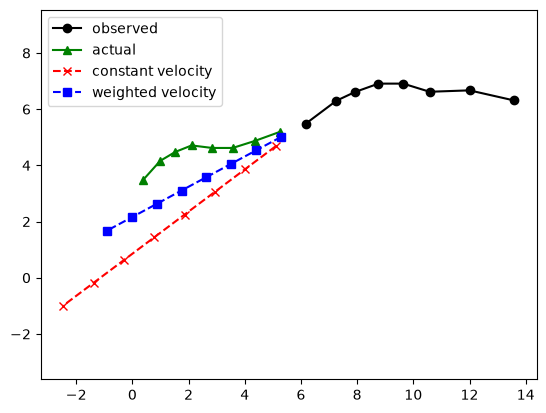

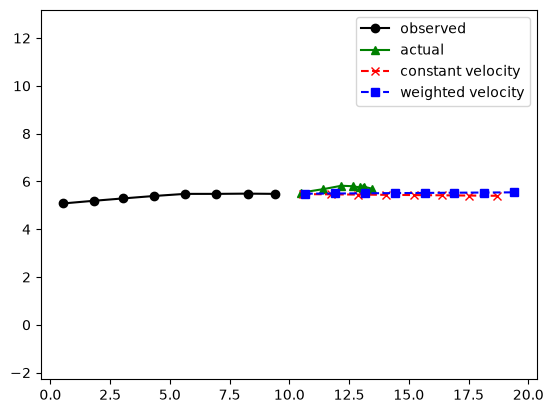

In [50]:
# 1. cut every person's path into windows: 8 observed points + 8 future points
path = df[df["id"] == pid].sort_values("frame")[["x", "y"]].values
all_obs = []
all_actual = []
for pid in df["id"].unique():
    path = df[df["id"] == pid][["x", "y"]].values
    start = 0
    while start + 16 <= len(path):
        all_obs.append(path[start:start + 8])
        all_actual.append(path[start + 8:start + 16])
        start = start + 4
print(len(all_obs), "windows")

# 2. ADE and FDE for both predictors at 3 steps (~1 s) and 8 steps (~3 s)
for n in [3, 8]:
    cv_ades = []
    cv_fdes = []
    wv_ades = []
    wv_fdes = []
    for i in range(len(all_obs)):
        actual = all_actual[i][:n]
        d_cv = np.sqrt(((cv_predict(all_obs[i], n) - actual) ** 2).sum(axis=1))   # error at each step
        d_wv = np.sqrt(((wv_predict(all_obs[i], n) - actual) ** 2).sum(axis=1))
        cv_ades.append(d_cv.mean())     # ADE = average over the steps
        cv_fdes.append(d_cv[-1])        # FDE = last step only
        wv_ades.append(d_wv.mean())
        wv_fdes.append(d_wv[-1])
    print(n, "steps | CV: ADE", round(np.mean(cv_ades), 3), "FDE", round(np.mean(cv_fdes), 3),
          "| WV: ADE", round(np.mean(wv_ades), 3), "FDE", round(np.mean(wv_fdes), 3))

# 3. pick the two example windows (cv_ades and wv_ades now hold the 8-step errors)
helps = int(np.argmax(np.array(cv_ades) - np.array(wv_ades)))   # where WV beats CV the most
fails = int(np.argmax(wv_ades))                                  # where WV is worst

# 4. plot them
for idx in [helps, fails]:
    obs = all_obs[idx]
    plt.figure()
    plt.plot(obs[:, 0], obs[:, 1], "ko-", label="observed")
    plt.plot(all_actual[idx][:, 0], all_actual[idx][:, 1], "g^-", label="actual")
    plt.plot(cv_predict(obs, 8)[:, 0], cv_predict(obs, 8)[:, 1], "rx--", label="constant velocity")
    plt.plot(wv_predict(obs, 8)[:, 0], wv_predict(obs, 8)[:, 1], "bs--", label="weighted velocity")
    plt.axis("equal")
    plt.legend()
    plt.show()

I tested both predictors on the ETH scene. From each person's path, I took windows of 8 observed positions (3.2 s) and 8 future positions (3.2 s), giving 275 windows. The predictors saw only the observed part, and I compared their guesses with the real future.

Measuring error:

ADE: the average distance between guess and truth over the predicted steps.

FDE: he distance at the last predicted step.

What it shows:

Over 1.2 s the two are almost the same, because people walk nearly straight over a short time.

Over 3.2 s the weighted predictor is better

Both get worse the further ahead they predict, and at 3.2 s the end point is off by about 1.3m.

Where it helps (Figure 1): the person curves, and constant velocity swings far off, while the weighted predictor stays closer.

Where it fails (Figure 2): the person walks briskly and then almost stops. Both predictors keep going at the old speed, because the past positions give no hint of a stop. 

Limits: the gain is small and measured on one scene, and overlapping windows from the same person aren't fully independent.

-----

Part C:

f.

What's missing:

Past positions show where a pedestrian has been, not where they intend to go. Two pedestrians with the same track can differ in intent (continue or cross), in whether they have noticed the buggy, and in the road context. None of this is in the (x, y) history, so a predictor that uses only positions cannot tell them apart. The same past can lead to several futures

Extra information:

I propose head and body orientation from the buggy's camera. People usually turn their head and shoulders toward the road before crossing. If a pedestrian slows down and faces the road, the predictor can widen or shift its prediction toward the road, or predict a stop, instead of a straight line.

New failure modes:

The orientation can be hidden (occlusion, distance, poor lighting, a pedestrian facing away) and the pose estimate is noisy. The cue can also mislead, for example when someone looks at their phone or glances at the road without crossing. Processing adds delay. This can cause false alarms, where the buggy brakes for nobody, or misses, where it trusts a wrong cue. So the cue should adjust the prediction's uncertainty and not replace the position-based model.

----